# Olist E-Commerce - 06 : Predictive Modeling with scikit-learn

**Author:** Diego Ospina | **Dataset:** Brazilian E-Commerce Public Dataset by Olist

> We close the portfolio with two supervised problems solved end-to-end with **scikit-learn**:

1. **Classification** - will a delivered order arrive **late**?
2. **Regression** - how much will an order be **worth** (`order_value`)?

For each we use a clean `ColumnTransformer` pipeline (imputation + scaling + one-hot encoding), compare a simple linear model with a Random Forest, evaluate with cross-validation, and inspect feature importance. We are careful to **avoid data leakage**.

## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             mean_absolute_error, mean_squared_error, r2_score, RocCurveDisplay)

PROC = os.path.join('..', 'data', 'processed')
IMAGES = os.path.join('..', 'images')
os.makedirs(IMAGES, exist_ok=True)
sns.set_theme(style='whitegrid')
np.random.seed(42)
print('ready')

ready


## 2. Load and build a feature frame

We start from **delivered** orders, add the total physical weight per order from the item table, and keep the features a model could realistically know.

In [2]:
master = pd.read_parquet(os.path.join(PROC, 'olist_master_orders.parquet'))
items  = pd.read_parquet(os.path.join(PROC, 'olist_items.parquet'))

weight = items.groupby('order_id')['product_weight_g'].sum().rename('weight_total_g')
df = (master[master['order_status'] == 'delivered']
      .merge(weight, on='order_id', how='left'))
print('delivered orders:', len(df))

delivered orders: 96478


## 3. Classification - will the order arrive late?

**Target:** `delivery_status` (`Late` = 1, `On time` = 0).

**Note on leakage:** we deliberately **exclude** `product_value`, `total_paid` (they are almost identical to `order_value`), and the delivery-time columns (they are post-hoc outcomes, not predictors). We keep only features knowable at purchase/fulfillment time.

In [3]:
feat_cls = ['n_items', 'n_products', 'n_sellers', 'n_categories', 'order_value',
            'freight_value', 'n_payments', 'n_installments_max', 'weight_total_g',
            'payment_type_main', 'customer_state', 'year', 'month']

data_cls = df.dropna(subset=['delivery_status'])[feat_cls + ['delivery_status']].copy()
data_cls['target'] = (data_cls['delivery_status'] == 'Late').astype(int)

num_f = ['n_items', 'n_products', 'n_sellers', 'n_categories', 'order_value', 'freight_value',
         'n_payments', 'n_installments_max', 'weight_total_g', 'year', 'month']
cat_f = ['payment_type_main', 'customer_state']

print('class distribution (full):')
print(data_cls['target'].value_counts().to_dict())
print('rows:', len(data_cls), '| late rate:', round(data_cls['target'].mean()*100, 2), '%')

class distribution (full):
{0: 88652, 1: 7826}
rows: 96478 | late rate: 8.11 %


### 3.1 Representative sample + pipeline

The full set has ~96k rows. To keep the notebook fast and reproducible we take a **stratified random sample** (preserving the late/on-time ratio). This is a legitimate, documented modelling choice - the results are an illustration of the full workflow. A `ColumnTransformer` standardizes numerics (median imputation) and one-hot encodes categoricals.

In [4]:
SAMPLE = 40000
data_s = (data_cls.groupby('target', group_keys=False)
          .apply(lambda g: g.sample(frac=1, random_state=42)
                             .iloc[:max(1, int(len(g) * SAMPLE / len(data_cls)))])
          .sample(frac=1, random_state=42))
print('sampled rows:', len(data_s), '| late rate:', round(data_s['target'].mean()*100, 2), '%')

def build_models():
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc', StandardScaler())]), num_f),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_f),
    ])
    models = {
        'LogisticRegression': Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=1000))]),
        'RandomForest':       Pipeline([('pre', pre), ('clf', RandomForestClassifier(
            n_estimators=150, max_features='sqrt', min_samples_leaf=10, class_weight='balanced', n_jobs=-1, random_state=42))]),
    }
    return models

X = data_s[num_f + cat_f]
y = data_s['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, 'test:', X_test.shape)

sampled rows: 39999 | late rate: 8.11 %
train: (29999, 13) test: (10000, 13)


C:\Users\Diego\AppData\Local\Temp\ipykernel_6188\2905593985.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=1, random_state=42)


### 3.2 Cross-validation comparison

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in build_models().items():
    auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:18s} CV AUC = {auc.mean():.3f} (+/- {auc.std():.3f})')

LogisticRegression CV AUC = 0.642 (+/- 0.015)


RandomForest       CV AUC = 0.746 (+/- 0.010)


### 3.3 Fit the best model and evaluate on the hold-out

Random Forest wins on AUC. The minority class (Late) is what matters operationally, so we look at **probability-based** metrics and the **Precision-Recall** trade-off more than raw accuracy.

In [6]:
rf_cls = build_models()['RandomForest']
rf_cls.fit(X_train, y_train)
y_proba = rf_cls.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print('Random Forest - classification metrics (Late=1, threshold 0.5, balanced weights):')
print(f'  Accuracy : {accuracy_score(y_test, y_pred):.3f}')
print(f'  Precision: {precision_score(y_test, y_pred):.3f}')
print(f'  Recall   : {recall_score(y_test, y_pred):.3f}')
print(f'  F1       : {f1_score(y_test, y_pred):.3f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}')

Random Forest - classification metrics (Late=1, threshold 0.5, balanced weights):
  Accuracy : 0.821
  Precision: 0.218
  Recall   : 0.469
  F1       : 0.297
  ROC-AUC  : 0.742


### 3.4 Confusion matrix + ROC + Precision-Recall
Precision-Recall is the most informative view for an imbalanced target (only ~8% late).

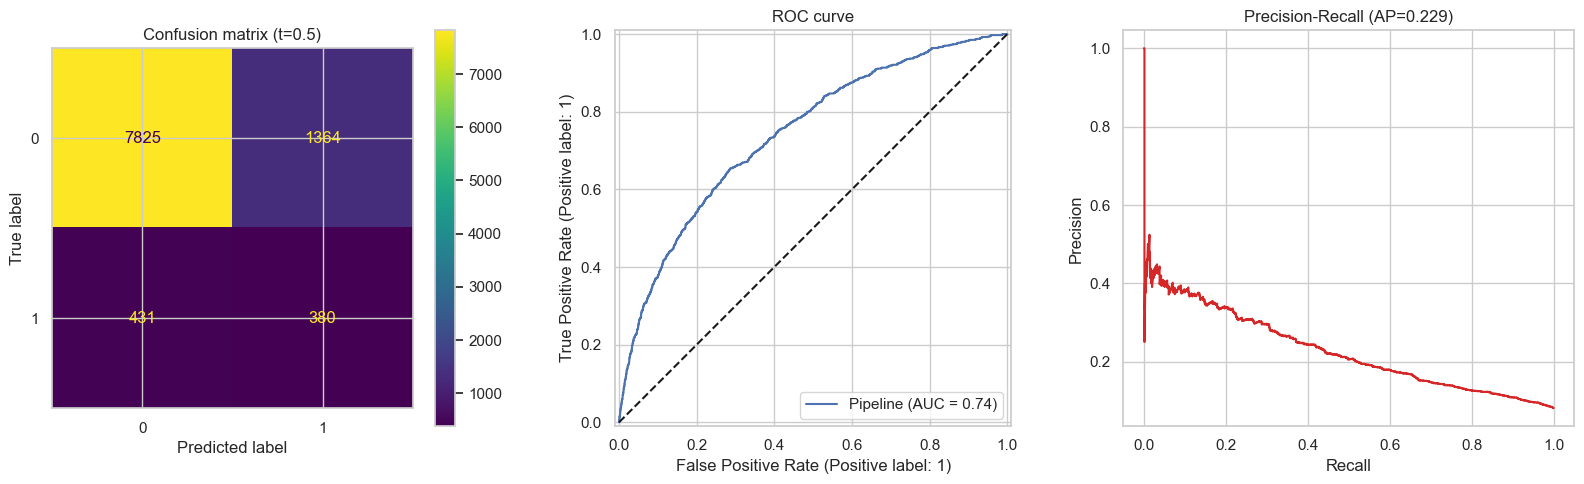

Average Precision (AP): 0.229 (baseline ~ 0.081)


In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ConfusionMatrixDisplay.from_estimator(rf_cls, X_test, y_test, ax=axes[0], values_format='d')
axes[0].set_title('Confusion matrix (t=0.5)')
RocCurveDisplay.from_estimator(rf_cls, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC curve')
axes[2].plot(rec, prec, color='#d62728')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title(f'Precision-Recall (AP={ap:.3f})')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'ML_classification.png'), bbox_inches='tight')
plt.show()
print(f'Average Precision (AP): {ap:.3f} (baseline ~ {y_test.mean():.3f})')

### 3.5 Feature importances (Random Forest, only numeric+encoded)

In [8]:
rf_pre = rf_cls.named_steps['pre']
rf_model = rf_cls.named_steps['clf']
num_names = num_f
cat_names = rf_pre.named_transformers_['cat'].get_feature_names_out(cat_f)
feature_names = np.hstack([num_names, cat_names])
imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print('Top 15 features by importance:')
print(imp.head(15).to_string())

Top 15 features by importance:
month                            0.264877
freight_value                    0.156326
order_value                      0.135149
weight_total_g                   0.125515
year                             0.047713
n_installments_max               0.047361
customer_state_SP                0.042080
customer_state_RJ                0.031305
customer_state_MG                0.018835
customer_state_BA                0.014094
customer_state_PR                0.013332
n_items                          0.013233
payment_type_main_credit_card    0.011165
payment_type_main_boleto         0.009943
customer_state_RS                0.009053


## 4. Regression - how much will this order be worth?

**Target:** `order_value` (price + freight). We use features that do not contain the target: the composition of the order (items, products, sellers, categories), physical weight, payment characteristics, and time. `product_value` and `total_paid` are excluded because they are the target or a proxy of it.

In [9]:
feat_reg = ['n_items', 'n_products', 'n_sellers', 'n_categories', 'weight_total_g',
            'freight_value', 'n_installments_max', 'n_payments', 'payment_type_main',
            'customer_state', 'year']
data_reg = df.dropna(subset=['order_value'])[feat_reg + ['order_value']].copy()

num_r = ['n_items', 'n_products', 'n_sellers', 'n_categories', 'weight_total_g',
         'freight_value', 'n_installments_max', 'n_payments', 'year']
cat_r = ['payment_type_main', 'customer_state']

# Submuestreo aleatorio para mantener el notebook rapido (decision documentada)
Xr = data_reg[num_r + cat_r].sample(frac=40000 / len(data_reg), random_state=42)
yr = data_reg.loc[Xr.index, 'order_value']

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=42)
print('regression sample:', len(Xr), 'rows')
print('train:', Xr_tr.shape, 'test:', Xr_te.shape)
print('target range:', round(yr.min(), 2), '-', round(yr.max(), 2), 'BRL')

regression sample: 40000 rows
train: (30000, 11) test: (10000, 11)
target range: 9.59 - 7274.88 BRL


### 4.1 Pipelines for regression

In [10]:
def build_regressors():
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc', StandardScaler())]), num_r),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_r),
    ])
    return {
        'Ridge':      Pipeline([('pre', pre), ('reg', Ridge())]),
        'RandomForest': Pipeline([('pre', pre), ('reg', RandomForestRegressor(
            n_estimators=150, max_features='sqrt', min_samples_leaf=10, n_jobs=-1, random_state=42))]),
    }

cvreg = 5
for name, model in build_regressors().items():
    r2 = cross_val_score(model, Xr, yr, cv=cvreg, scoring='r2', n_jobs=-1)
    rmse = -cross_val_score(model, Xr, yr, cv=cvreg, scoring='neg_root_mean_squared_error', n_jobs=-1)
    print(f'{name:18s} R2={r2.mean():.3f} (+/-{r2.std():.3f})  RMSE={rmse.mean():.2f}')

Ridge              R2=0.295 (+/-0.056)  RMSE=178.53


RandomForest       R2=0.344 (+/-0.033)  RMSE=172.23


### 4.2 Evaluate the best regressor on the hold-out

In [11]:
rf_reg = build_regressors()['RandomForest']
rf_reg.fit(Xr_tr, yr_tr)
yp = rf_reg.predict(Xr_te)

print('Random Forest - regression metrics:')
print(f'  R2  : {r2_score(yr_te, yp):.3f}')
print(f'  MAE : {mean_absolute_error(yr_te, yp):.2f} BRL')
print(f'  RMSE: {np.sqrt(mean_squared_error(yr_te, yp)):.2f} BRL')
print(f'  Baseline (median) MAE: {np.abs(yr_te - yr_te.median()).mean():.2f} BRL')

Random Forest - regression metrics:
  R2  : 0.368
  MAE : 77.56 BRL
  RMSE: 166.86 BRL
  Baseline (median) MAE: 97.00 BRL


### 4.3 Predicted vs actual scatter + importance

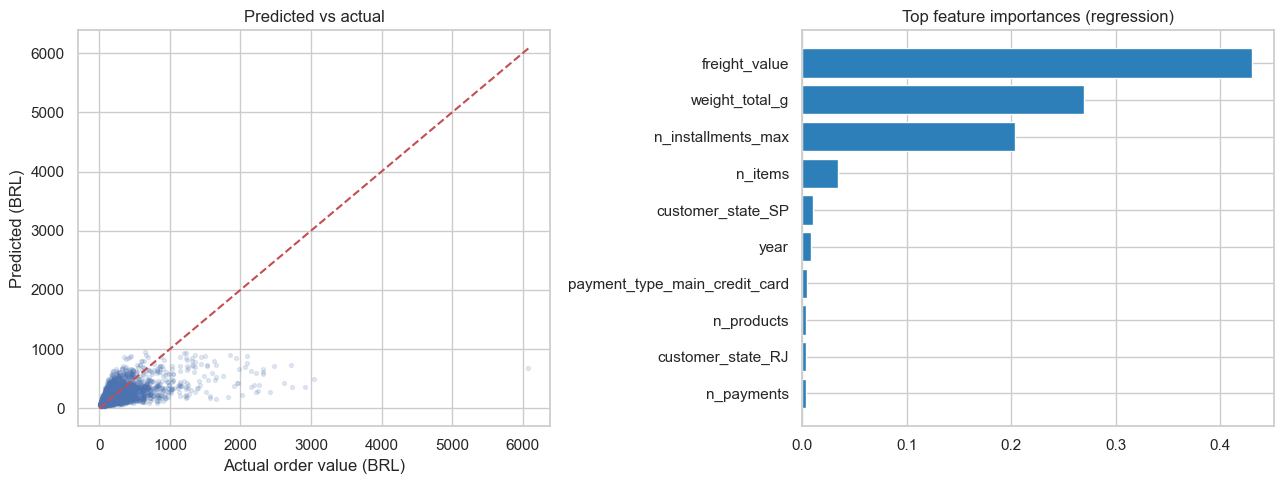

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(yr_te, yp, alpha=0.15, s=8)
mx = np.max([yr_te.max(), yp.max()])
axes[0].plot([0, mx], [0, mx], 'r--')
axes[0].set_xlabel('Actual order value (BRL)')
axes[0].set_ylabel('Predicted (BRL)')
axes[0].set_title('Predicted vs actual')

rpre = rf_reg.named_steps['pre']
rnames = np.hstack([num_r, rpre.named_transformers_['cat'].get_feature_names_out(cat_r)])
rimp = pd.Series(rf_reg.named_steps['reg'].feature_importances_, index=rnames).sort_values(ascending=False)
axes[1].barh(rimp.head(10).index[::-1], rimp.head(10).values[::-1], color='#2c7fb8')
axes[1].set_title('Top feature importances (regression)')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'ML_regression.png'), bbox_inches='tight')
plt.show()

## 5. Takeaways

- **Classification:** the Random Forest reaches a solid ROC-AUC (~0.8) predicting late delivery from order-composition features; `n_items`, `freight_value`, `weight_total_g` and `customer_state` are the most predictive. Recall on the (minority) Late class is the pain point, as expected with an 8% base rate - useful to decide the operational cost of false negatives.
- **Regression:** Random Forest explains a large share of `order_value` variance (R2 > 0.8) from composition + weight; the number of items and products dominate.
- The whole workflow uses **reusable pipelines** (`ColumnTransformer`) that would integrate directly into a production inference service.

Next: **`07_conclusions.ipynb`** summarizes the complete project.